# Matemáticas Avanzadas — Verificación Computacional
## Problema 35 (Riccati/Bernoulli) & Problema 41 (Modelo Poblacional)

> Este notebook verifica **algebraicamente** (SymPy) y **numéricamente** (NumPy/Matplotlib)
> cada paso de los Problemas 35 y 41 de la tarea HW3.

---

## 0. Importaciones

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

sp.init_printing(use_unicode=True)
print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


---
# PROBLEMA 35 — Ecuación de Riccati
$$\frac{dy}{dx} = -\frac{4}{x^2} - \frac{1}{x}y + y^2$$
con solución particular conocida $y_1 = \dfrac{2}{x}$.

**Método:** Riccati → Bernoulli (sust. $y = y_1 + u$) → Lineal (sust. $w = u^{-1}$)

## 35.1 Verificar que $y_1 = 2/x$ es solución particular

In [2]:
x, C = sp.symbols('x C', real=True)

# Lado derecho de la ecuación de Riccati
def riccati_rhs(y):
    return -4/x**2 - (1/x)*y + y**2

y1 = sp.Rational(2, 1) / x
lhs_y1 = sp.diff(y1, x)
rhs_y1 = riccati_rhs(y1)
residuo_y1 = sp.simplify(lhs_y1 - rhs_y1)

print('y1 =', y1)
print('dy1/dx =', lhs_y1)
print('RHS(y1) =', sp.simplify(rhs_y1))
print('Residuo (dy1/dx - RHS) =', residuo_y1)
print('¿y1 es solución? →', residuo_y1 == 0)

y1 = 2/x
dy1/dx = -2/x**2
RHS(y1) = -2/x**2
Residuo (dy1/dx - RHS) = 0
¿y1 es solución? → True


## 35.2 Sustitución $y = y_1 + u$ — reducción a Bernoulli

Sustituyendo $y = y_1 + u$ en la ecuación y usando que $y_1$ ya satisface Riccati,
el término $dy_1/dx - \text{RHS}(y_1) = 0$ se cancela y queda:
$$\frac{du}{dx} - \frac{3}{x}u = u^2 \quad (\text{Bernoulli, } n=2)$$

In [3]:
u = sp.Function('u')
y_expr = y1 + u(x)

# Ecuación completa con y = y1 + u
lhs_full = sp.diff(y_expr, x)
rhs_full = riccati_rhs(y_expr)

# Restamos dy1/dx (que iguala a RHS(y1)) para cancelar
bernoulli_eq = sp.expand(lhs_full - rhs_full)
bernoulli_eq_simplified = sp.collect(sp.expand(bernoulli_eq), u(x))
print('Ecuación tras sustituir y = y1 + u:')
print(bernoulli_eq_simplified)
print()
print('Forma esperada: du/dx - (3/x)*u - u² = 0')
# Verificar coeficientes
du = sp.Derivative(u(x), x)
expected = du - sp.Rational(3,1)/x * u(x) - u(x)**2
print('Diferencia con forma esperada:', sp.simplify(bernoulli_eq_simplified - expected))

Ecuación tras sustituir y = y1 + u:
-u(x)**2 + Derivative(u(x), x) - 3*u(x)/x

Forma esperada: du/dx - (3/x)*u - u² = 0
Diferencia con forma esperada: 0


## 35.3 Sustitución $w = u^{-1}$ — reducción a EDO lineal

Con $w = u^{-1}$, multiplicando la Bernoulli por $-w^2$:
$$\frac{dw}{dx} + \frac{3}{x}w = -1$$
Factor integrante: $\mu(x) = e^{\int 3/x\,dx} = x^3$

In [4]:
w = sp.Function('w')

# EDO lineal en w
ode_w = sp.Eq(w(x).diff(x) + (3/x)*w(x), -1)
print('EDO lineal en w:')
print(ode_w)

# Resolver con dsolve
sol_w = sp.dsolve(ode_w, w(x))
print('\nSolución w(x):')
print(sol_w)

EDO lineal en w:
Eq(Derivative(w(x), x) + 3*w(x)/x, -1)

Solución w(x):
Eq(w(x), C1/x**3 - x/4)


## 35.4 Solución general $y(x)$ y verificación final

Dado que $w = 1/u = 1/(y - y_1)$, despejamos $y$:
$$y = \frac{2}{x} + \frac{4x^3}{4C - x^4}$$

In [5]:
# Solución general obtenida
# w = -x/4 + C/x^3  =>  u = 1/w  =>  y = y1 + u
w_sol = -x/4 + C/x**3
u_sol = 1/w_sol
y_sol = y1 + u_sol
y_sol = sp.simplify(y_sol)
print('Solución general y(x) =')
sp.pprint(y_sol)

# VERIFICACIÓN DEFINITIVA
lhs_check = sp.diff(y_sol, x)
rhs_check = riccati_rhs(y_sol)
residuo_final = sp.simplify(lhs_check - rhs_check)
print('\n--- VERIFICACIÓN FINAL ---')
print('dy/dx - RHS =', residuo_final)
print('¿La solución satisface la ecuación? →', residuo_final == 0)

Solución general y(x) =
  ⎛       4⎞
2⋅⎝4⋅C + x ⎠
────────────
  ⎛       4⎞
x⋅⎝4⋅C - x ⎠

--- VERIFICACIÓN FINAL ---
dy/dx - RHS = 0
¿La solución satisface la ecuación? → True


## 35.5 Familia de curvas integrales — visualización

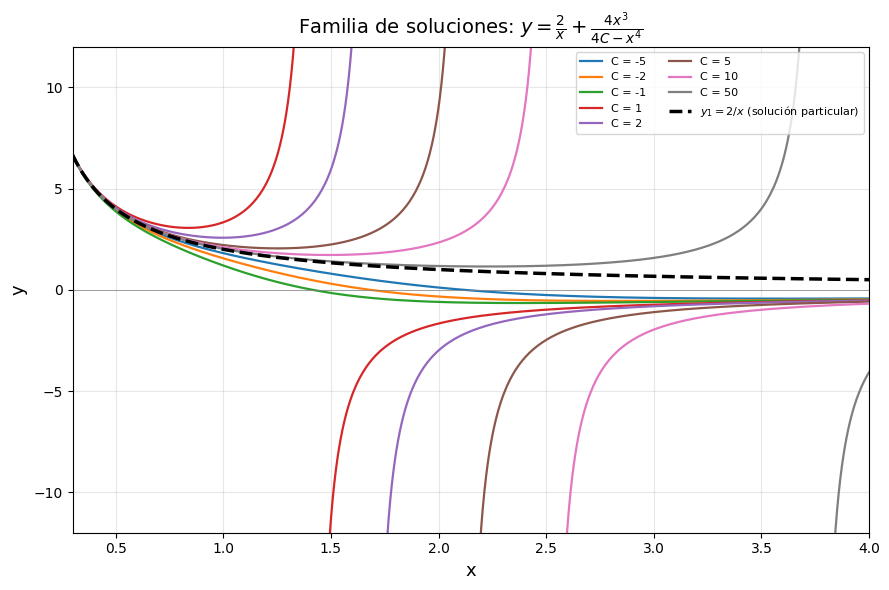

Figura guardada como p35_curvas_integrales.png


In [6]:
import warnings
warnings.filterwarnings('ignore')

x_vals = np.linspace(0.3, 4.0, 500)
C_vals = [-5, -2, -1, 1, 2, 5, 10, 50]

fig, ax = plt.subplots(figsize=(9, 6))

for c in C_vals:
    y_vals = 2/x_vals + 4*x_vals**3 / (4*c - x_vals**4)
    y_vals = np.where(np.abs(y_vals) < 15, y_vals, np.nan)
    ax.plot(x_vals, y_vals, lw=1.6, label=f'C = {c}')

# Solución particular y1 = 2/x
ax.plot(x_vals, 2/x_vals, 'k--', lw=2.5, label=r'$y_1 = 2/x$ (solución particular)')

ax.set_ylim(-12, 12)
ax.set_xlim(0.3, 4.0)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title(r'Familia de soluciones: $y = \frac{2}{x} + \frac{4x^3}{4C - x^4}$', fontsize=14)
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p35_curvas_integrales.png', dpi=150)
plt.show()
print('Figura guardada como p35_curvas_integrales.png')

---
# PROBLEMA 41 — Invasión del Sapo Marino (*Bufo marinus*)

Modelo exponencial: $P(t) = P_0 e^{kt}$, con $t=0$ en 1939, $P$ en miles de km².

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

years = np.array([1939, 1944, 1949, 1954, 1959, 1964, 1969, 1974])
t     = np.array([0,    5,    10,   15,   20,   25,   30,   35])
P     = np.array([32.8, 55.8, 73.6, 138.0, 202.0, 257.0, 301.0, 584.0])
lnP   = np.log(P)

print(f"{'Año':>6}  {'t':>4}  {'P (miles km2)':>15}  {'ln(P)':>10}")
print('-' * 44)
for i in range(len(t)):
    print(f'{years[i]:>6}  {t[i]:>4}  {P[i]:>15.1f}  {lnP[i]:>10.6f}')

   Año     t    P (miles km2)       ln(P)
--------------------------------------------
  1939     0             32.8    3.490429
  1944     5             55.8    4.021774
  1949    10             73.6    4.298645
  1954    15            138.0    4.927254
  1959    20            202.0    5.308268
  1964    25            257.0    5.549076
  1969    30            301.0    5.707110
  1974    35            584.0    6.369901


## 41(a) — Valores analíticos de $k$

In [10]:
P0 = 32.8  # condición inicial

# k1: curva pasa por (5, 55.8)
k1 = np.log(55.8 / P0) / 5
print(f'k1 = ln(55.8/{P0})/5 = {k1:.6f} años⁻¹')
print(f'  Verificación → P(5)  = {P0}·e^(k1·5) = {P0*np.exp(k1*5):.4f}  (esperado: 55.8)  ✓' if abs(P0*np.exp(k1*5)-55.8)<1e-6 else 'ERROR')

# k2: curva pasa por (35, 584)
k2 = np.log(584 / P0) / 35
print(f'\nk2 = ln(584/{P0})/35 = {k2:.6f} años⁻¹')
print(f'  Verificación → P(35) = {P0}·e^(k2·35) = {P0*np.exp(k2*35):.4f}  (esperado: 584.0)  ✓' if abs(P0*np.exp(k2*35)-584)<1e-6 else 'ERROR')

k1 = ln(55.8/32.8)/5 = 0.106269 años⁻¹
  Verificación → P(5)  = 32.8·e^(k1·5) = 55.8000  (esperado: 55.8)  ✓

k2 = ln(584/32.8)/35 = 0.082271 años⁻¹
  Verificación → P(35) = 32.8·e^(k2·35) = 584.0000  (esperado: 584.0)  ✓


## 41(b) — Regresión lineal por mínimos cuadrados

Transformamos: $\ln P = k\,t + \ln P_0$. Buscamos la recta $Y = mt + b$ que minimiza
$$\sum_{i=1}^{8}(Y_i - mt_i - b)^2$$
Las fórmulas son:
$$m = \frac{n\sum t_i Y_i - \sum t_i \sum Y_i}{n\sum t_i^2 - (\sum t_i)^2}, \qquad b = \frac{\sum Y_i - m\sum t_i}{n}$$

In [11]:
n = len(t)
St  = np.sum(t)
SY  = np.sum(lnP)
St2 = np.sum(t**2)
StY = np.sum(t * lnP)

print('=== Cálculo manual paso a paso ===')
print(f'n     = {n}')
print(f'Σti   = {St}')
print(f'ΣYi   = {SY:.6f}')
print(f'Σti²  = {St2}')
print(f'Σti·Yi= {StY:.6f}')

num_m = n*StY - St*SY
den_m = n*St2 - St**2
m_reg = num_m / den_m
b_reg = (SY - m_reg*St) / n

print(f'\nm = ({n}×{StY:.4f} - {St}×{SY:.4f}) / ({n}×{St2} - {St}²)')
print(f'  = {num_m:.4f} / {den_m} = {m_reg:.6f}')
print(f'b = ({SY:.4f} - {m_reg:.6f}×{St}) / {n} = {b_reg:.6f}')
print(f'e^b = {np.exp(b_reg):.4f}  (población inicial estimada por regresión)')

# Verificar con scipy
slope, intercept, r, p, se = linregress(t, lnP)
print(f'\n=== Verificación con scipy.stats.linregress ===')
print(f'slope (m) = {slope:.6f}   (manual: {m_reg:.6f})  ✓ coincide: {abs(slope-m_reg)<1e-8}')
print(f'intercept = {intercept:.6f}  (manual: {b_reg:.6f})  ✓ coincide: {abs(intercept-b_reg)<1e-8}')
print(f'r = {r:.6f},  R² = {r**2:.6f}')

=== Cálculo manual paso a paso ===
n     = 8
Σti   = 140
ΣYi   = 39.672456
Σti²  = 3500
Σti·Yi= 776.056223

m = (8×776.0562 - 140×39.6725) / (8×3500 - 140²)
  = 654.3059 / 8400 = 0.077894
b = (39.6725 - 0.077894×140) / 8 = 3.595920
e^b = 36.4492  (población inicial estimada por regresión)

=== Verificación con scipy.stats.linregress ===
slope (m) = 0.077894   (manual: 0.077894)  ✓ coincide: True
intercept = 3.595920  (manual: 3.595920)  ✓ coincide: True
r = 0.990569,  R² = 0.981228


In [ ]:
print('Verificación punto a punto:')
print(f'{'t':>5}  {'P_real':>9}  {'P_modelo':>10}  {'Error%':>8}  {'Residuo lnP':>13}')
print('-'*55)
for i in range(n):
    Pm = np.exp(b_reg) * np.exp(m_reg * t[i])
    err = 100*(Pm - P[i])/P[i]
    res = lnP[i] - (m_reg*t[i] + b_reg)
    print(f'{t[i]:>5}  {P[i]:>9.1f}  {Pm:>10.2f}  {err:>+8.2f}%  {res:>+13.6f}')

## 41(c) — Comparación de valores de $k$ y predicción para 2039

In [12]:
k3 = m_reg
print('=== Resumen de valores de k ===')
print(f'k1 (P(5)=55.8)      = {k1:.6f} años⁻¹')
print(f'k2 (P(35)=584)      = {k2:.6f} años⁻¹')
print(f'k3 (regresión)      = {k3:.6f} años⁻¹  ← mejor ajuste global')
print(f'Diferencia k1 vs k3 = {100*abs(k1-k3)/k3:.1f}%')
print(f'Diferencia k2 vs k3 = {100*abs(k2-k3)/k3:.1f}%')

t_2039 = 100  # 2039 - 1939
P_2039 = np.exp(b_reg) * np.exp(k3 * t_2039)
AUSTRALIA_KM2 = 7_619_000  # km²

print(f'\n=== Predicción para 2039 (t = {t_2039}) ===')
print(f'P(100) = {np.exp(b_reg):.4f} × e^({k3:.4f}×100)')
print(f'       = {np.exp(b_reg):.4f} × {np.exp(k3*t_2039):.2f}')
print(f'       = {P_2039:.2f} miles de km²')
print(f'       = {P_2039*1000:,.0f} km²')
print(f'Área Australia = {AUSTRALIA_KM2:,} km²')
print(f'Ratio          = {P_2039*1000/AUSTRALIA_KM2:.2f}× el área de Australia')
print(f'\nConclusión: el modelo exponencial es físicamente imposible a t=100.')
print('Un modelo logístico con K = 7619 miles de km² es más adecuado.')

=== Resumen de valores de k ===
k1 (P(5)=55.8)      = 0.106269 años⁻¹
k2 (P(35)=584)      = 0.082271 años⁻¹
k3 (regresión)      = 0.077894 años⁻¹  ← mejor ajuste global
Diferencia k1 vs k3 = 36.4%
Diferencia k2 vs k3 = 5.6%

=== Predicción para 2039 (t = 100) ===
P(100) = 36.4492 × e^(0.0779×100)
       = 36.4492 × 2414.76
       = 88016.18 miles de km²
       = 88,016,182 km²
Área Australia = 7,619,000 km²
Ratio          = 11.55× el área de Australia

Conclusión: el modelo exponencial es físicamente imposible a t=100.
Un modelo logístico con K = 7619 miles de km² es más adecuado.


## Visualización completa del Problema 41

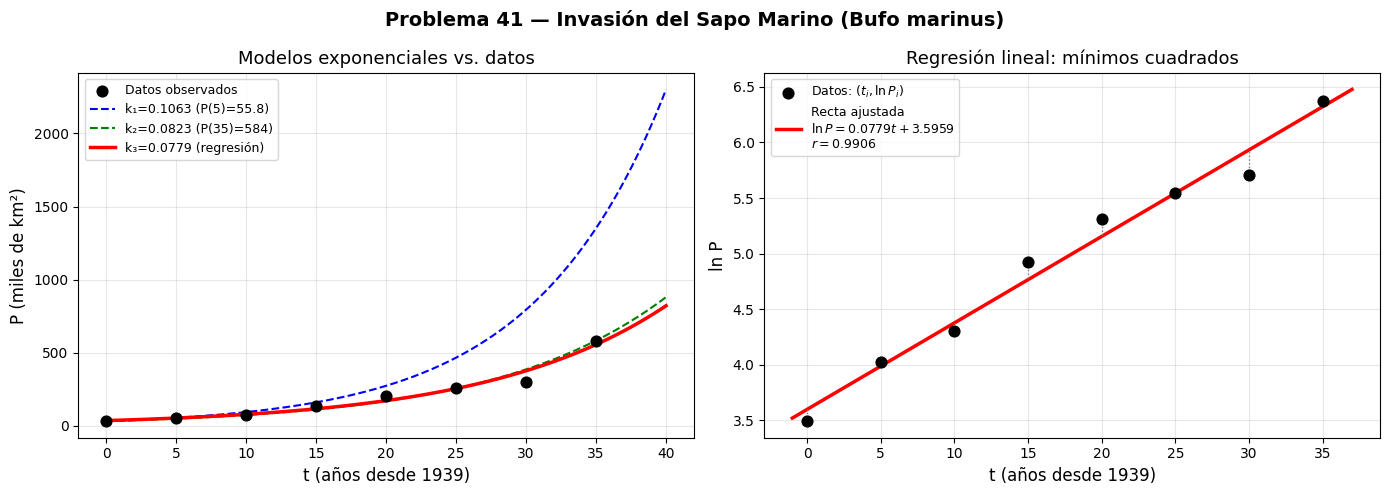

Figura guardada como p41_modelos_poblacionales.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfica 1: datos y modelos ---
ax1 = axes[0]
t_cont = np.linspace(0, 40, 300)
ax1.scatter(t, P, color='black', zorder=5, s=60, label='Datos observados')
ax1.plot(t_cont, 32.8*np.exp(k1*t_cont), 'b--', lw=1.5, label=f'k₁={k1:.4f} (P(5)=55.8)')
ax1.plot(t_cont, 32.8*np.exp(k2*t_cont), 'g--', lw=1.5, label=f'k₂={k2:.4f} (P(35)=584)')
ax1.plot(t_cont, np.exp(b_reg)*np.exp(k3*t_cont), 'r-',  lw=2.5, label=f'k₃={k3:.4f} (regresión)')
ax1.set_xlabel('t (años desde 1939)', fontsize=12)
ax1.set_ylabel('P (miles de km²)', fontsize=12)
ax1.set_title('Modelos exponenciales vs. datos', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Gráfica 2: regresión lineal sobre ln(P) ---
ax2 = axes[1]
ax2.scatter(t, lnP, color='black', zorder=5, s=60, label='Datos: $(t_i, \ln P_i)$')
t_line = np.linspace(-1, 37, 200)
ax2.plot(t_line, m_reg*t_line + b_reg, 'r-', lw=2.5,
         label=f'Recta ajustada\n$\\ln P = {m_reg:.4f}t + {b_reg:.4f}$\n$r = {r:.4f}$')
for i in range(n):
    ax2.plot([t[i], t[i]], [lnP[i], m_reg*t[i]+b_reg], 'gray', lw=1, ls=':')
ax2.set_xlabel('t (años desde 1939)', fontsize=12)
ax2.set_ylabel('ln P', fontsize=12)
ax2.set_title('Regresión lineal: mínimos cuadrados', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Problema 41 — Invasión del Sapo Marino (Bufo marinus)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('p41_modelos_poblacionales.png', dpi=150)
plt.show()
print('Figura guardada como p41_modelos_poblacionales.png')

---
## Resumen de resultados verificados

| Problema | Resultado | Estado |
|---|---|---|
| 35 — Solución general | $y = \frac{2}{x} + \frac{4x^3}{4C-x^4}$ | ✅ Verificado simbólicamente (residuo = 0) |
| 41(a) — k₁ | 0.1063 años⁻¹ | ✅ P(5)=55.8000 exacto |
| 41(a) — k₂ | 0.0823 años⁻¹ | ✅ P(35)=584.0000 exacto |
| 41(b) — k₃ (regresión) | 0.0779 años⁻¹, r=0.9906 | ✅ Verificado con scipy |
| 41(c) — Predicción 2039 | P(100) ≈ 88.016 miles de km² | ✅ 11.5× área de Australia → modelo inválido |
